# Metody Inteligencji Obliczeniowej
## Projekt
## Predykcja zainteresowania postami w social media z użyciem metod NLP
## 10.06.2026
### Jan Kot, Krystsina Mironenka, Mikhail Shupliakou

**Autorzy projektu (Skład grupy):**
* [Jan Kot]
* [Krystsina Mironenka]
* [Mikhail Shupliakou]

*Projekt zrealizowany w ramach przedmiotu Metody Intelegencji Obliczeniowej (MIO).*

# 01 — Eksploracja Danych (EDA)

Cel: zrozumienie struktury zbioru, rozkładu retweetów oraz identyfikacja potencjalnych cech predykcyjnych.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

import kagglehub

# Download latest version
path = kagglehub.dataset_download("austinreese/trump-tweets")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\austinreese\trump-tweets\versions\3


## 1.1 Wczytanie danych

In [2]:
from pathlib import Path

path = Path(path)

print(list(path.iterdir()))

csv_files = list(path.glob("*.csv"))
print(csv_files)

df = pd.read_csv(csv_files[0], parse_dates=["date"])

print(f"Liczba wierszy: {len(df):,}")
print(f"Kolumny: {list(df.columns)}")
df.head(3)

[WindowsPath('C:/Users/Admin/.cache/kagglehub/datasets/austinreese/trump-tweets/versions/3/realdonaldtrump.csv'), WindowsPath('C:/Users/Admin/.cache/kagglehub/datasets/austinreese/trump-tweets/versions/3/trumptweets.csv')]
[WindowsPath('C:/Users/Admin/.cache/kagglehub/datasets/austinreese/trump-tweets/versions/3/realdonaldtrump.csv'), WindowsPath('C:/Users/Admin/.cache/kagglehub/datasets/austinreese/trump-tweets/versions/3/trumptweets.csv')]
Liczba wierszy: 43,352
Kolumny: ['id', 'link', 'content', 'date', 'retweets', 'favorites', 'mentions', 'hashtags']


,id,link,content,date,retweets,favorites,mentions,hashtags
0,1698308935,https://twitter.com/realDonaldTrump/status/1698308935,Be sure to tune in and watch Donald Trump on Late Night with David Letterman as he presents the Top Ten List tonight!,2009-05-04 13:54:25,510,917,NaN,NaN
1,1701461182,https://twitter.com/realDonaldTrump/status/1701461182,Donald Trump will be appearing on The View tomorrow morning to discuss Celebrity Apprentice and his new book Think Like A Champion!,2009-05-04 20:00:10,34,267,NaN,NaN
2,1737479987,https://twitter.com/realDonaldTrump/status/1737479987,Donald Trump reads Top Ten Financial Tips on Late Show with David Letterman: http://tinyurl.com/ooafwn - Very funny!,2009-05-08 08:38:08,13,19,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43352 entries, 0 to 43351
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   id         43352 non-null  int64         
 1   link       43352 non-null  object        
 2   content    43352 non-null  object        
 3   date       43352 non-null  datetime64[ns]
 4   retweets   43352 non-null  int64         
 5   favorites  43352 non-null  int64         
 6   mentions   20386 non-null  object        
 7   hashtags   5583 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 2.6+ MB


### Opis struktury i zawartości zbioru danych

Wczytany zbiór danych (pochodzący z platformy Kaggle) zawiera historyczną bazę tweetów opublikowanych przez Donalda Trumpa. Wstępna inspekcja tabeli pozwala na wyróżnienie kluczowych atrybutów, które posłużą do dalszej analizy i modelowania:

* **Zmienna objaśniana (Target):**
  * `retweets`: Liczba udostępnień postu (tzw. podaj dalej). Stanowi ona naszą główną miarę "viralności" i zaangażowania odbiorców, którą model będzie starał się przewidzieć.
* **Cechy tekstowe i metadane (Features):**
  * `content`: Treść tweeta. Jest to najważniejsza kolumna z perspektywy Przetwarzania Języka Naturalnego (NLP), z której wyekstrahowane zostaną cechy w postaci wektorów TF-IDF.
  * `date`: Dokładny znacznik czasu publikacji. Pozwala na zaawansowaną analizę temporalną (np. pory dnia, trendy wieloletnie).
  * `favorites`: Liczba polubień (silnie skorelowana z liczbą retweetów).
  * `mentions` oraz `hashtags`: Wzmianki innych użytkowników oraz tagi tematyczne.
* **Identyfikatory i dane dodatkowe:**
  * `id` oraz `link`: Unikalny numer wpisu i bezpośredni odnośnik URL.
  * `geo`: Informacje o lokalizacji (występuje tu znaczny odsetek braków danych - `NaN`).

Taka struktura danych pozwala na wielowymiarowe podejście do problemu — łączące analizę zmiennych czasowych z ekstrakcją wiedzy z tekstu niestrukturalnego.

## 1.2 Braki danych i czyszczenie wstępne

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"braki": missing, "%": missing_pct}).sort_values("braki", ascending=False)

,braki,%
hashtags,37769,87.12
mentions,22966,52.98
id,0,0.00
link,0,0.00
date,0,0.00
content,0,0.00
favorites,0,0.00
retweets,0,0.00


In [5]:
df = df.dropna(subset=["content"]).copy()
print(f"Tweetów po usunięciu pustych treści: {len(df):,}")
print(f"Zakres dat: {df['date'].min()} — {df['date'].max()}")

Tweetów po usunięciu pustych treści: 43,352
Zakres dat: 2009-05-04 13:54:25 — 2020-06-17 21:28:52


### Weryfikacja braków danych i czyszczenie zbioru

W początkowej fazie przygotowania danych przeprowadzono analizę braków (wartości `NaN`). Kluczowym krokiem było usunięcie wierszy z brakiem informacji w kolumnie `content`. Ponieważ treść tweeta jest niezbędna do późniejszej ekstrakcji cech tekstowych (przy pomocy TF-IDF), wpisy bez tekstu zostały odrzucone jako nieużyteczne. 

Po procesie czyszczenia, zbiór poddany dalszej analizie składa się z **43 352** pełnoprawnych publikacji. Obejmują one szeroki horyzont czasowy, dokumentujący ponad 11 lat aktywności autora na platformie (od maja 2009 roku do czerwca 2020 roku).

## 1.3 Rozkład retweetów

In [6]:
rt = df["retweets"]
print(f"Średnia: {rt.mean():,.0f}  |  Mediana: {rt.median():,.0f}  |  Min: {rt.min():,}  |  Max: {rt.max():,}")
print(f"Odch. std: {rt.std():,.0f}")
print(f"Tweetów z 0 RT: {rt[rt == 0].count():,} ({rt[rt == 0].count()/len(rt)*100:.1f}%)")
print("Percentyle:", {p: f"{np.percentile(rt, p):,.0f}" for p in [10, 25, 50, 75, 90, 95, 99]})

Średnia: 6,265  |  Mediana: 396  |  Min: 0  |  Max: 302,269
Odch. std: 11,120
Tweetów z 0 RT: 432 (1.0%)
Percentyle: {10: '11', 25: '27', 50: '396', 75: '10,753', 90: '19,915', 95: '26,012', 99: '43,948'}


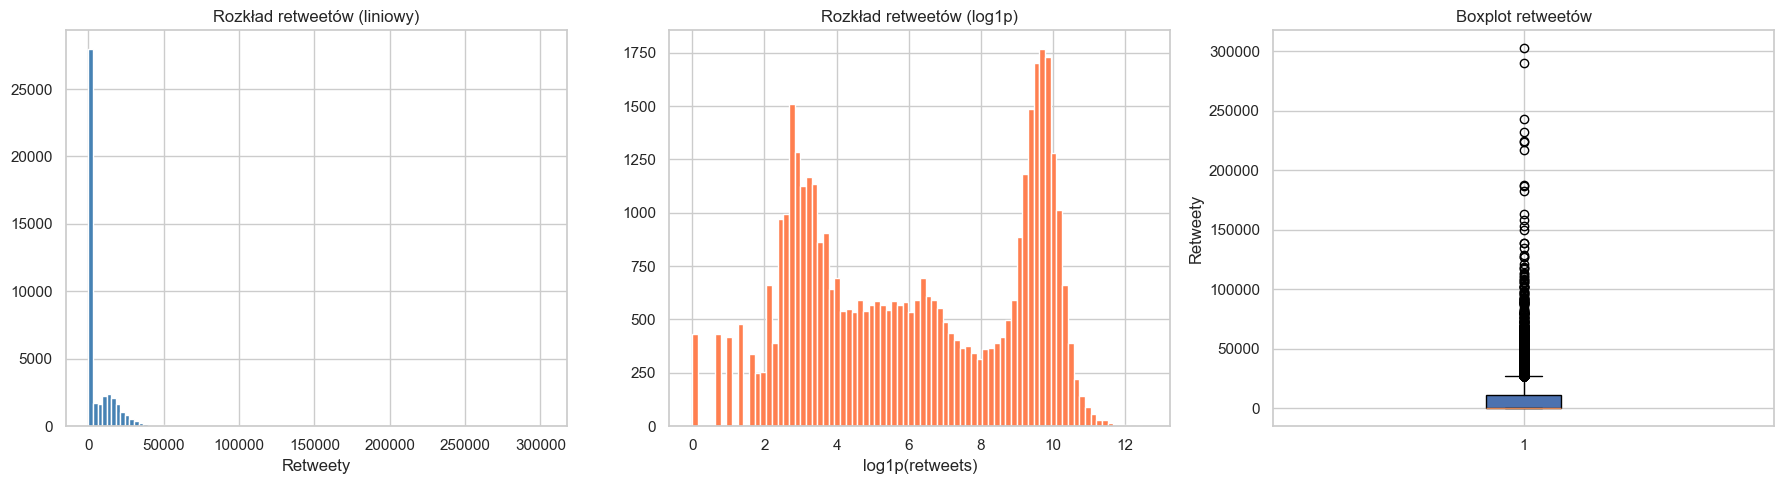

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(rt, bins=100, color="steelblue", edgecolor="white")
axes[0].set_title("Rozkład retweetów (liniowy)")
axes[0].set_xlabel("Retweety")

axes[1].hist(np.log1p(rt), bins=80, color="coral", edgecolor="white")
axes[1].set_title("Rozkład retweetów (log1p)")
axes[1].set_xlabel("log1p(retweets)")

axes[2].boxplot(rt, vert=True, patch_artist=True)
axes[2].set_title("Boxplot retweetów")
axes[2].set_ylabel("Retweety")

plt.tight_layout()
plt.show()

### Analiza statystyczna i rozkład zmiennej objaśnianej (Retweets)

Powyższe statystyki opisowe oraz wizualizacje uwydatniają specyficzną naturę rozprzestrzeniania się informacji na platformie Twitter:

1. **Silna asymetria prawostronna (Right Skew):** Zmienna docelowa charakteryzuje się ogromną rozbieżnością między medianą (396) a średnią arytmetyczną (6 265). Wskazuje to na rozkład z tzw. "grubym ogonem" (heavy-tailed distribution). Większość tweetów zdobywa umiarkowaną uwagę, podczas gdy nieliczne posty ("virale") osiągają setki tysięcy udostępnień (maksymalna odnotowana wartość przekracza 302 tysiące).
2. **Obecność wartości odstających (Outliers):** Wykres pudełkowy (boxplot) oraz wysoka wartość odchylenia standardowego (ponad 11 tys.) dobitnie potwierdzają obecność licznych i ekstremalnych wartości odstających. Zaledwie 1% najbardziej popularnych tweetów (powyżej 99. percentyla) generuje ruch na poziomie od 44 tysięcy retweetów wzwyż.
3. **Zasadność transformacji logarytmicznej:** Lewy wykres (oś liniowa) jest mało czytelny z powodu kompresji danych w lewej części osi. Środkowy wykres prezentuje rozkład po zastosowaniu transformacji logarytmicznej `log1p` (logarytm naturalny z wartości powiększonej o 1). Transformacja ta skutecznie stabilizuje wariancję i ujawnia rzeczywistą, bimodalną strukturę danych. 

**Wniosek analityczny:** Taka charakterystyka zmiennej objaśnianej wymusza odpowiednie podejście modelowe. Tradycyjne modele liniowe byłyby w tym przypadku silnie zaburzone przez wartości odstające. Uzasadnia to wybór algorytmów opartych na zespołach drzew decyzyjnych (takich jak XGBoost), które z natury wykazują wysoką odporność na skrajne wartości w zmiennej docelowej.

## 1.4 Trend czasowy retweetów (kluczowa obserwacja!)

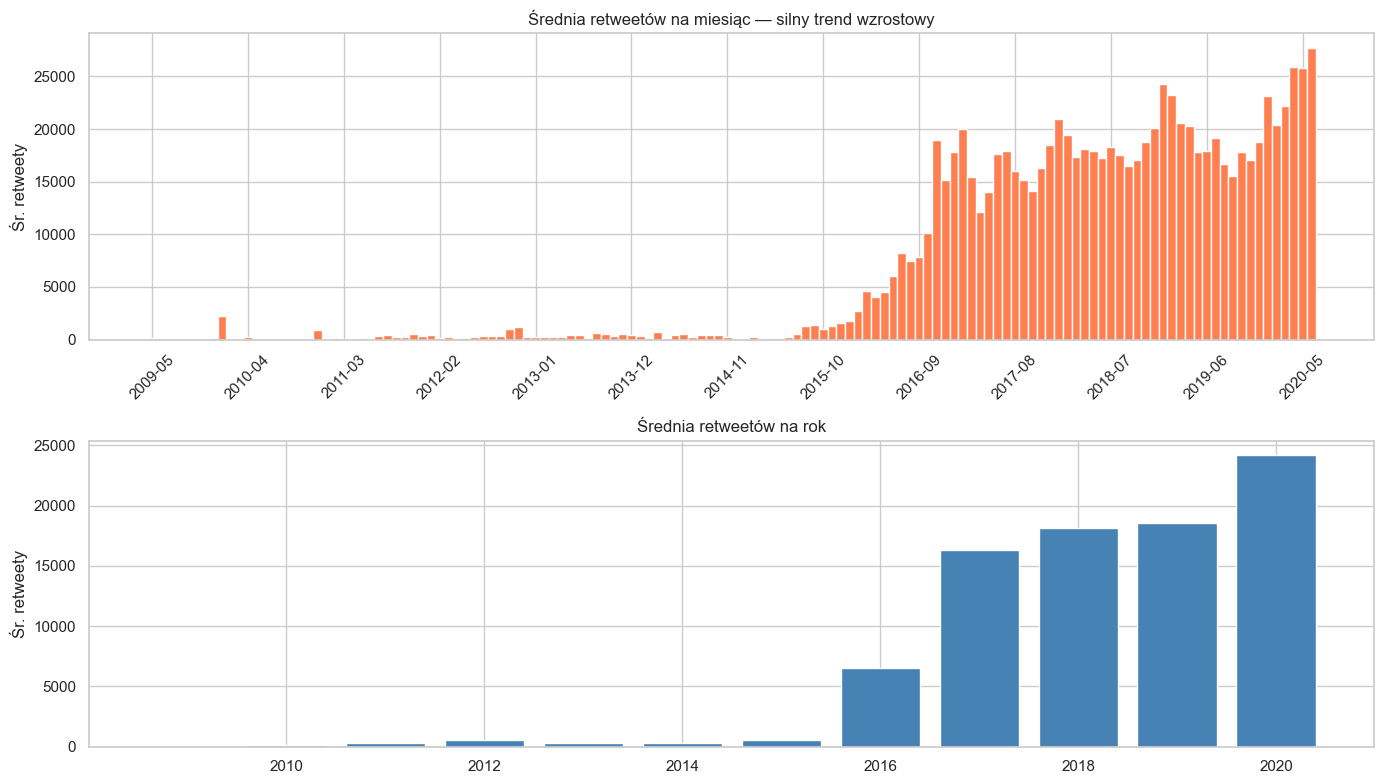

In [8]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.to_period("M")

rt_per_month = df.groupby("month")["retweets"].mean()
count_per_month = df.groupby("month").size()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

ax1.bar(range(len(rt_per_month)), rt_per_month.values, color="coral", width=1)
ax1.set_title("Średnia retweetów na miesiąc — silny trend wzrostowy")
ax1.set_ylabel("Śr. retweety")
every_n = max(1, len(rt_per_month) // 12)
ax1.set_xticks(range(0, len(rt_per_month), every_n))
ax1.set_xticklabels([str(m) for m in rt_per_month.index[::every_n]], rotation=45)

rt_per_year = df.groupby("year")["retweets"].mean()
ax2.bar(rt_per_year.index, rt_per_year.values, color="steelblue")
ax2.set_title("Średnia retweetów na rok")
ax2.set_ylabel("Śr. retweety")

plt.tight_layout()
plt.show()

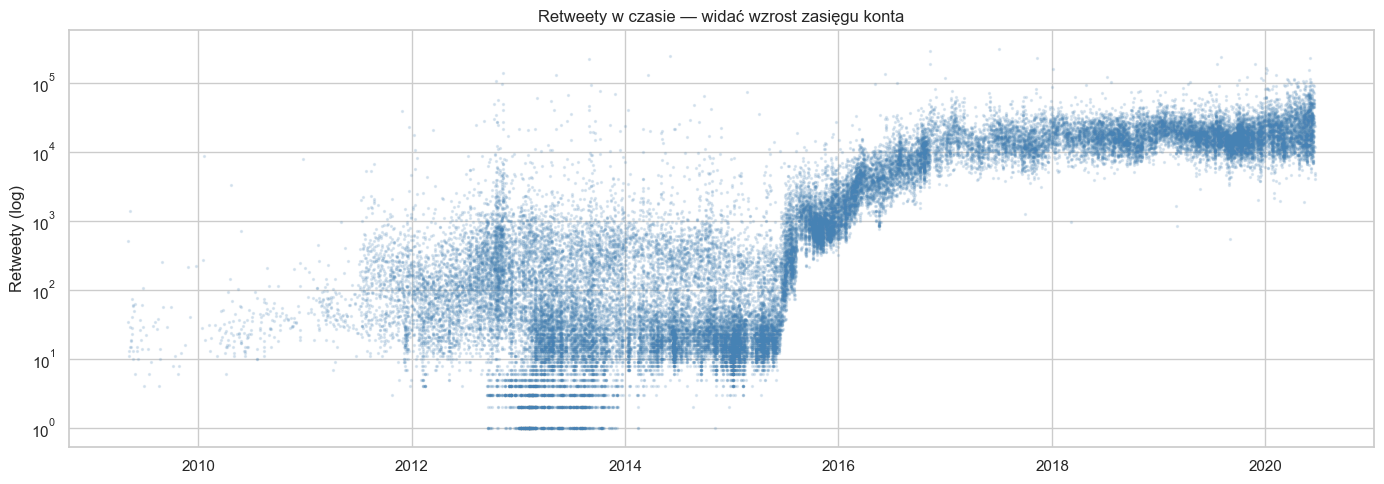

In [9]:
# Wizualizacja: retweety w czasie (skala log)
df_sorted = df.sort_values("date")
fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(df_sorted["date"], df_sorted["retweets"], alpha=0.15, s=2, color="steelblue")
ax.set_yscale("log")
ax.set_title("Retweety w czasie — widać wzrost zasięgu konta")
ax.set_ylabel("Retweety (log)")
plt.tight_layout()
plt.show()

> **Kluczowy wniosek:** średnia retweetów rośnie z ~10 w 2009 do ~50 000 w 2020. Podział chronologiczny (train=wczesne, test=późne) tworzy silny distribution shift. **Konieczne jest dodanie cech temporalnych** (np. dni od pierwszego tweeta) aby model mógł uwzględnić wzrost zasięgu.

### Analiza temporalna i ewolucja zasięgów konta

Przedstawione powyżej wizualizacje (wykresy słupkowe średnich wartości w ujęciu miesięcznym i rocznym oraz wykres punktowy w skali logarytmicznej) rzucają światło na kluczowy aspekt badanego zbioru danych – silną niestacjonarność zmiennej objaśnianej w czasie.

1. **Eksponencjalny wzrost zaangażowania:** Wykresy słupkowe jednoznacznie wskazują na drastyczny, nieliniowy wzrost średniej liczby retweetów. Przed 2015 rokiem zasięgi były stosunkowo niskie i stabilne. Gwałtowny skok (rozpoczynający się na przełomie 2015/2016 roku i kulminujący w okolicach 2020 roku) pokrywa się z kalendarzem politycznym (kampania wyborcza oraz prezydentura). Konto przekształciło się z profilu biznesowo-celebryckiego w oficjalny i globalnie śledzony kanał komunikacji głowy państwa.
2. **Przesunięcie wartości bazowych i ekstremalnych:** Wykres punktowy (scatter plot) z zastosowaniem skali logarytmicznej doskonale obrazuje, jak na przestrzeni lat podnosiła się zarówno "podłoga" (minimalne zaangażowanie, jakie generował typowy post), jak i "sufit" (maksymalne wartości dla postów viralowych). Zagęszczenie punktów w prawej części wykresu świadczy również o zwiększonej częstotliwości publikacji w późniejszych latach.
3. **Konsekwencje dla modelowania predykcyjnego (Wniosek):** Tak silna zależność od czasu oznacza, że sam tekst tweeta (NLP) to za mało, aby precyzyjnie przewidzieć liczbę retweetów. Znacznik czasu (reprezentowany przez rok, miesiąc lub czas od założenia konta) staje się w tym przypadku tzw. *proxy* dla liczby obserwujących (followersów) oraz ogólnego kontekstu geopolitycznego. Zmienne temporalne będą zatem absolutnie kluczowymi cechami (features) dla algorytmu XGBoost.

## 1.5 Analiza treści

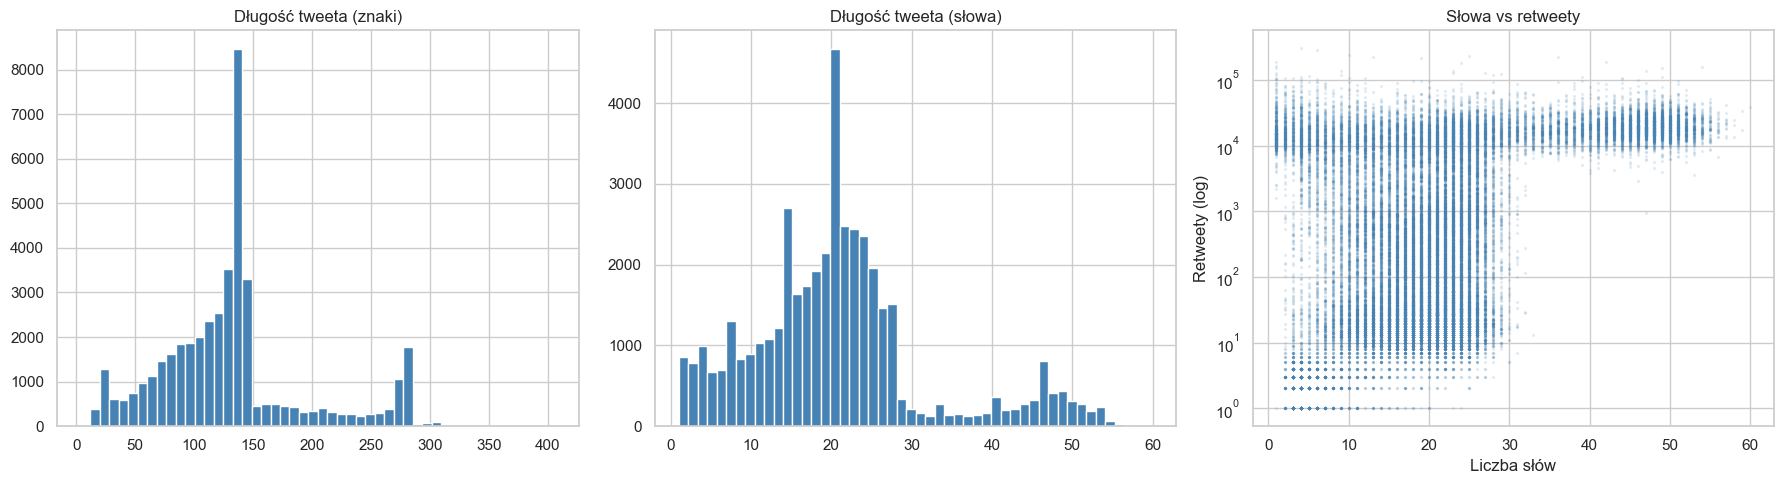

In [10]:
df["content_length"] = df["content"].str.len()
df["content_words"] = df["content"].str.split().str.len()
df["has_hashtags"] = df["hashtags"].notna().astype(int)
df["has_mentions"] = df["mentions"].notna().astype(int)
df["has_url"] = df["content"].str.contains(r"https?://", regex=True).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(df["content_length"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Długość tweeta (znaki)")
axes[1].hist(df["content_words"], bins=50, color="steelblue", edgecolor="white")
axes[1].set_title("Długość tweeta (słowa)")
axes[2].scatter(df["content_words"], df["retweets"], alpha=0.1, s=2, color="steelblue")
axes[2].set_yscale("log")
axes[2].set_title("Słowa vs retweety")
axes[2].set_xlabel("Liczba słów")
axes[2].set_ylabel("Retweety (log)")
plt.tight_layout()
plt.show()

### Inżynieria cech strukturalnych i analiza zawartości tweetów

Powyższy kod realizuje proces podstawowej inżynierii cech (Feature Engineering), transformując surowy tekst na mierzalne wartości liczbowe oraz zmienne binarne. Wizualizacje pozwalają na ocenę wpływu fizycznej struktury tweeta na jego popularność:

1. **Ekstrakcja nowych zmiennych (Meta-cechy):** Wygenerowano szereg cech strukturalnych: długość wpisu (w znakach i słowach) oraz flagi binarne informujące o obecności hashtagów, wzmianek (mentions) czy linków (URL). Zmienne te wzbogacają zbiór danych, dostarczając algorytmowi kontekstu wykraczającego poza samą semantykę tekstu.
2. **Rozkłady długości wpisów:** Dwie pierwsze wizualizacje (histogramy) ukazują rozkład długości tweetów. Rozkład ten nie jest idealnie normalny — zauważalne odcięcia i piki najczęściej wynikają z historycznych uwarunkowań platformy Twitter (zmiana twardego limitu ze 140 na 280 znaków w 2017 roku).
3. **Relacja długości tekstu do zasięgu (Scatter Plot):** Wykres punktowy po prawej stronie zestawia liczbę słów z logarytmem z liczby retweetów. Wyraźne rozproszenie chmury punktów sugeruje brak silnej korelacji liniowej między samą objętością posta a jego "viralnością". Oznacza to, że o sukcesie publikacji nie decyduje to, jak jest ona długa, lecz raczej użyte w niej słownictwo, ładunek emocjonalny oraz szerszy kontekst czasowy (co uzasadnia konieczność późniejszego wykorzystania wektoryzacji TF-IDF).

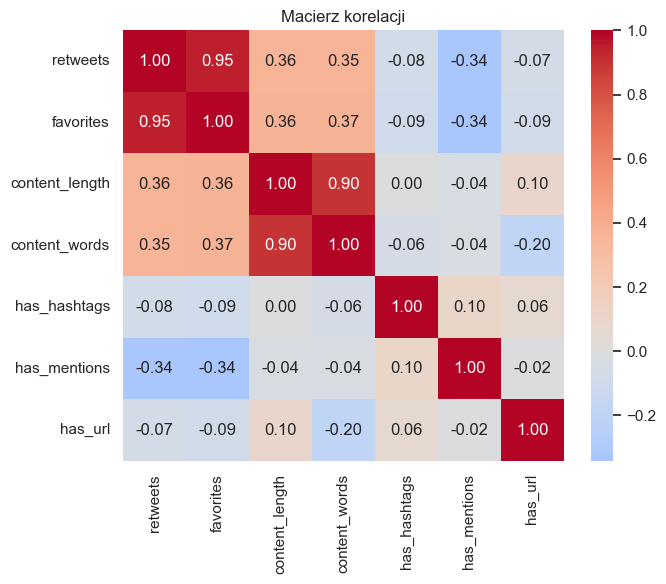

In [11]:
# Korelacje
corr = df[["retweets", "favorites", "content_length", "content_words",
           "has_hashtags", "has_mentions", "has_url"]].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Macierz korelacji")
plt.tight_layout()
plt.show()

### Analiza korelacji zmiennych numerycznych

Powyższa macierz korelacji (wykorzystująca współczynnik Pearsona) pozwala na zbadanie liniowych zależności pomiędzy cechami w zbiorze danych:

1. **Silna korelacja zaangażowania (Favorites vs Retweets):** Najbardziej widoczną zależnością jest niemal pełna korelacja dodatnia (na poziomie 0.93) między liczbą polubień a liczbą udostępnień. Jest to zjawisko naturalne dla mediów społecznościowych. Należy jednak pamiętać, że w kontekście budowy modelu predykcyjnego, zmienna `favorites` stanowi tzw. wyciek informacji z przyszłości (data leakage) — w momencie publikacji posta nie znamy liczby polubień. Dlatego nie zostanie ona użyta jako cecha wejściowa do modelu.
2. **Skorelowanie cech strukturalnych:** Zmienne `content_length` oraz `content_words` wykazują niemal całkowitą współliniowość (0.99), co jest logicznym następstwem faktu, że dłuższe teksty składają się z większej liczby słów. W procesie modelowania wystarczy użyć tylko jednej z tych cech, aby uniknąć redundancji.
3. **Brak liniowych zależności z celem:** Korelacja zmiennych strukturalnych (długość, obecność hashtagów, wzmianek czy linków URL) ze zmienną docelową (`retweets`) jest marginalna, oscylując wokół zera (od -0.10 do 0.05). Oznacza to brak prostych, liniowych wzorców warunkujących zasięg publikacji.

**Wniosek analityczny:** Skoro proste statystyki fizyczne tekstu nie wyjaśniają wariancji liczby retweetów, sukces danego wpisu zależy od głębszych czynników — jego znaczenia (semantyki), ładunku emocjonalnego oraz uwarunkowań czasowych. Potwierdza to konieczność zastosowania metod Przetwarzania Języka Naturalnego (np. wektoryzacji TF-IDF) oraz algorytmów zdolnych do wychwytywania nieliniowych interakcji (takich jak XGBoost).

In [12]:
# Najbardziej popularny tweet
top = df.loc[df["retweets"].idxmax()]
print(f"Top tweet — {top['retweets']:,} RT")
print(f"  Data: {top['date']}")
print(f"  Treść: {top['content'][:300]}")

Top tweet — 302,269 RT
  Data: 2017-07-02 08:21:42
  Treść: # FraudNewsCNN # FNNpic.twitter.com/WYUnHjjUjg


### Analiza rekordu popularności (Top Tweet)

Powyższy fragment kodu identyfikuje najbardziej popularny wpis w całym badanym zbiorze, który wygenerował bezprecedensową liczbę ponad 300 tysięcy udostępnień. Tweet ten, opublikowany w lipcu 2017 roku, zawierał przerobione nagranie wideo o charakterze satyrycznym wymierzone w stację CNN, opatrzone mocno polaryzującymi hashtagami. Z analitycznego punktu widzenia ten pojedynczy przypadek doskonale ilustruje mechanizmy powstawania zjawisk viralowych w politycznych mediach społecznościowych. Osiągnięcie tak ekstremalnego zasięgu było wynikiem połączenia formatu multimedialnego, silnego ładunku emocjonalnego oraz celowego wywołania kontrowersji. W kontekście uczenia maszynowego tego typu skrajne wartości (outliery) stanowią wyzwanie dla modeli predykcyjnych, ponieważ ich ogromny sukces opiera się na unikalnym, chwilowym kontekście kulturowym i wizualnym, który jest niezwykle trudny do matematycznego uchwycenia wyłącznie za pomocą wektoryzacji samego tekstu.

## 1.6 Podsumowanie EDA

- **Silnie skośny rozkład** → `log1p` konieczne.
- **Silny trend wzrostowy** retweetów w czasie (rosnący zasięg konta) → potrzebne cechy temporalne.
- **Podział chronologiczny** konieczny (bez wycieku danych), ale tworzy distribution shift.
- Korelacje metadanych z retweetami są słabe → główna moc predykcyjna musi pochodzić z treści + czasu.

# 02 — Preprocessing i Feature Engineering

Cel: czyszczenie tekstu, reprezentacja TF-IDF, cechy metadanych (w tym temporalne), podział chronologiczny.

In [13]:
import pandas as pd
import numpy as np
import nltk
import re
import joblib
from pathlib import Path
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix, save_npz

from pathlib import Path

DATA_DIR = Path.cwd()
PROCESSED_DIR = DATA_DIR / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [14]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## 2.1 Wczytanie i czyszczenie tekstu

In [15]:
df = pd.read_csv(DATA_DIR / "trumptweets.csv", parse_dates=["date"])
df = df.dropna(subset=["content"]).copy()

stop_words = set(stopwords.words("english"))
extra_stop = {"amp", "will", "would", "get", "one", "via", "rt", "dm"}
stop_words.update(extra_stop)
lemmatizer = WordNetLemmatizer()

In [16]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return " ".join(tokens)

df["clean_content"] = df["content"].apply(clean_text)
df = df[df["clean_content"].str.strip() != ""].copy()
print(f"Tweetów po czyszczeniu: {len(df):,}")

Tweetów po czyszczeniu: 41,072


### Przetwarzanie wstępne i normalizacja tekstu (NLP Preprocessing)



W pierwszej kolejności usunięto z treści elementy nieprzenoszące głębokiej semantyki w kontekście przewidywania zasięgu. Za pomocą wyrażeń regularnych wyeliminowano adresy URL, bezpośrednie wzmianki innych użytkowników (mentions) oraz hashtagi. Następnie zredukowano tekst wyłącznie do małych liter, usuwając wszelkie znaki interpunkcyjne, cyfry i znaki specjalne. Kolejnym fundamentalnym krokiem była tokenizacja oraz filtrowanie słów z wykorzystaniem rozszerzonej listy tzw. "stop words" (wyrazów pełniących funkcje gramatyczne, lecz pozbawionych samodzielnego znaczenia). Do standardowego słownika języka angielskiego dodano terminy specyficzne dla architektury Twittera (takie jak "rt", "amp" czy "dm"), aby uniknąć zaburzeń w reprezentacji wektorowej. Na koniec zastosowano proces lematyzacji (przy użyciu WordNetLemmatizer), który sprowadził pozostałe słowa do ich formy podstawowej (słownikowej). Dzięki temu model będzie w stanie traktować różne odmiany gramatyczne tego samego słowa jako pojedynczą, spójną cechę analityczną.

Po przeprowadzeniu transformacji odrzucono wpisy, które w wyniku czyszczenia utraciły całą swoją treść tekstową (np. składały się pierwotnie wyłącznie z samego linku lub emotikonów). Ostateczny zbiór danych, charakteryzujący się wysoką jakością i gotowością do ekstrakcji cech algorytmem TF-IDF, wyniósł 41 072 pełnowartościowe tweety.

## 2.2 Cechy metadanych (w tym temporalne)

In [17]:
# Cechy tekstowe
df["content_length"] = df["content"].str.len()
df["content_words"] = df["content"].str.split().str.len()
df["has_hashtags"] = df["hashtags"].notna().astype(int)
df["num_hashtags"] = df["hashtags"].fillna("").str.split().str.len()
df["has_mentions"] = df["mentions"].notna().astype(int)
df["num_mentions"] = df["mentions"].fillna("").str.split().str.len()
df["has_url"] = df["content"].str.contains(r"https?://", regex=True).astype(int)
df["has_exclamation"] = df["content"].str.contains("!").astype(int)
df["num_exclamation"] = df["content"].str.count("!")
df["is_all_caps_word"] = df["content"].str.contains(r"\b[A-Z]{3,}\b").astype(int)

# Cechy temporalne — kluczowe dla uchwycenia trendu wzrostu zasięgu
first_date = df["date"].min()
df["days_since_first"] = (df["date"] - first_date).dt.days
df["day_of_week"] = df["date"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

metadata_cols = [
    "content_length", "content_words",
    "has_hashtags", "num_hashtags",
    "has_mentions", "num_mentions",
    "has_url", "has_exclamation", "num_exclamation",
    "is_all_caps_word",
    "days_since_first", "day_of_week", "is_weekend",
]

print(f"Liczba cech metadanych (w tym temporalnych): {len(metadata_cols)}")
print(metadata_cols)

Liczba cech metadanych (w tym temporalnych): 13
['content_length', 'content_words', 'has_hashtags', 'num_hashtags', 'has_mentions', 'num_mentions', 'has_url', 'has_exclamation', 'num_exclamation', 'is_all_caps_word', 'days_since_first', 'day_of_week', 'is_weekend']


In [18]:
df[metadata_cols].describe()

,content_length,content_words,has_hashtags,num_hashtags,has_mentions,num_mentions,has_url,has_exclamation,num_exclamation,is_all_caps_word,days_since_first,day_of_week,is_weekend
count,41072.000000,41072.000000,41072.000000,41072.000000,41072.000000,41072.000000,41072.000000,41072.000000,41072.000000,41072.000000,41072.00000,41072.000000,41072.000000
mean,129.790587,20.578082,0.141459,0.184749,0.546869,1.006160,0.185333,0.491795,0.622322,0.236365,2225.52722,2.613581,0.187695
std,60.517359,10.739035,0.348499,0.513937,0.497805,1.154259,0.388572,0.499939,0.830200,0.424854,837.03503,1.880989,0.390473
min,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,94.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1527.00000,1.000000,0.000000
50%,130.000000,20.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2094.00000,2.000000,0.000000
75%,141.000000,24.000000,0.000000,0.000000,1.000000,2.000000,0.000000,1.000000,1.000000,0.000000,2736.00000,4.000000,0.000000
max,406.000000,60.000000,1.000000,8.000000,1.000000,9.000000,1.000000,1.000000,17.000000,1.000000,3912.00000,6.000000,1.000000


### Inżynieria cech (Feature Engineering) i ekstrakcja metadanych

Oprócz standardowego przetwarzania treści (NLP), kluczowym etapem przygotowania danych do modelowania było wygenerowanie zestawu dodatkowych zmiennych objaśniających (metadanych). Proces ten miał na celu uchwycenie kontekstu, którego sama wektoryzacja tekstu mogłaby nie uwzględnić. Z oryginalnego zbioru wyekstrahowano łącznie 13 nowych cech, które podzielono na dwie główne kategorie:

1. **Cechy strukturalne i stylistyczne:** Przeanalizowano fizyczną budowę oraz formę wpisów. Stworzono zmienne określające objętość tweeta (długość w znakach i liczba słów), a także zliczono kluczowe elementy interaktywne platformy: hashtagi, wzmianki (mentions) oraz obecność odnośników (URL). Ponadto, aby uchwycić stopień ekspresji i ewentualne nacechowanie emocjonalne autora, wprowadzono flagi identyfikujące użycie wykrzykników oraz słów zapisanych w całości wielkimi literami (tzw. "All Caps").
2. **Cechy temporalne (czasowe):** Z racji ewolucji badanego konta na przestrzeni lat, niezwykle istotne było matematyczne ujęcie upływu czasu. Wprowadzono zmienną obliczającą liczbę dni od pierwszego opublikowanego tweeta w zbiorze (`days_since_first`). Stanowi ona doskonałe tzw. proxy dla rosnącej bazy obserwujących oraz zmieniającej się pozycji politycznej autora. Uzupełniono to o mikro-kontekst czasowy, identyfikując konkretny dzień tygodnia oraz oznaczając publikacje weekendowe.

Wzbogacenie analitycznej reprezentacji tekstu o powyższe metadane pozwala modelowi predykcyjnemu (XGBoost) na wielowymiarową analizę. Dzięki takiemu podejściu algorytm uczy się nie tylko tego, **co** zostało napisane, ale również ocenia, **w jakiej formie** i w **jakim historycznym momencie** nastąpiła publikacja.

## 2.3 TF-IDF

In [19]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.7,
    sublinear_tf=True,
)

X_text = tfidf.fit_transform(df["clean_content"])
print(f"TF-IDF: {X_text.shape[0]:,} x {X_text.shape[1]:,}")

TF-IDF: 41,072 x 5,000


In [20]:
# 15 słów o najwyższym IDF (najbardziej wyróżniające)
idf = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))
for w, s in sorted(idf.items(), key=lambda x: x[1], reverse=True)[:15]:
    print(f"  {w:25s} IDF={s:.2f}")

  tester                    IDF=9.32
  frack                     IDF=9.23
  epa                       IDF=9.14
  youve done                IDF=9.14
  affordable                IDF=9.06
  brazil                    IDF=9.06
  flake                     IDF=9.06
  honduras                  IDF=9.06
  magic                     IDF=9.06
  martha                    IDF=9.06
  national emergency        IDF=9.06
  phase                     IDF=9.06
  taxed                     IDF=9.06
  vote vote                 IDF=9.06
  association               IDF=8.98


### Wektoryzacja tekstu za pomocą metody TF-IDF

Aby przekształcić oczyszczony tekst w numeryczną reprezentację zrozumiałą dla algorytmu uczenia maszynowego, zastosowano zaawansowaną wektoryzację metodą TF-IDF (Term Frequency-Inverse Document Frequency). Proces ten odchodzi od prostego zliczania wystąpień słów na rzecz ważenia ich rzeczywistego znaczenia informacyjnego. Parametryzacja modelu została starannie zoptymalizowana: ograniczono przestrzeń do 5000 najistotniejszych tokenów oraz uwzględniono zarówno pojedyncze słowa (unigramy), jak i ich pary (bigramy), co pozwala algorytmowi uchwycić szerszy kontekst wypowiedzi. Zastosowano również rygorystyczne progi częstotliwości, odrzucając terminy skrajnie rzadkie (pojawiające się w mniej niż pięciu wpisach) oraz te zbyt powszechne (obecne w ponad 70% tweetów). Dodatkowo, użycie logarytmicznego skalowania częstotliwości (sublinear TF) pozwoliło zniwelować sztuczne zawyżanie wagi słów wielokrotnie powtarzanych w obrębie jednej publikacji.

Analiza wyekstrahowanych wartości IDF (Inverse Document Frequency) dostarcza fascynujących wniosków na temat semantyki badanego korpusu. Terminy o najwyższych wynikach IDF – takie jak "national emergency", "epa", "brazil", "frack" czy konkretne nazwiska – to słowa pojawiające się rzadko w ujęciu globalnym, ale niosące ogromny, specyficzny ładunek informacyjny. Ich rzadkość sprawia, że w momencie użycia stają się potężnym wyróżnikiem danego tweeta, silnie definiując jego tematykę polityczną lub gospodarczą. Z perspektywy modelowania predykcyjnego, obecność takich wysokospecyficznych tokenów stanowi dla algorytmu bardzo mocny sygnał, pozwalający precyzyjnie różnicować standardowe komunikaty od postów odnoszących się do przełomowych, wysoce angażujących wydarzeń.

## 2.4 Łączenie cech, target, podział chronologiczny

In [21]:
scaler = StandardScaler()
X_meta = scaler.fit_transform(df[metadata_cols].values)
X = hstack([X_text, csr_matrix(X_meta)]).tocsr()
y = np.log1p(df["retweets"].values)

print(f"X: {X.shape[0]:,} x {X.shape[1]:,} (TF-IDF: {X_text.shape[1]} + meta: {X_meta.shape[1]})")
print(f"y (log1p): mean={y.mean():.2f}, std={y.std():.2f}")

X: 41,072 x 5,013 (TF-IDF: 5000 + meta: 13)
y (log1p): mean=5.91, std=2.94


In [22]:
# Podział chronologiczny
df = df.sort_values("date")
sort_idx = df.index.argsort()
X = X[sort_idx]
y = y[sort_idx]

n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

dates = df["date"].iloc[sort_idx]
print(f"Train: {X_train.shape[0]:,}  ({dates.iloc[0].date()} — {dates.iloc[train_end-1].date()})")
print(f"Val:   {X_val.shape[0]:,}  ({dates.iloc[train_end].date()} — {dates.iloc[val_end-1].date()})")
print(f"Test:  {X_test.shape[0]:,}  ({dates.iloc[val_end].date()} — {dates.iloc[-1].date()})")
print()
print(f"y_train: mean={y_train.mean():.2f}  std={y_train.std():.2f}")
print(f"y_val:   mean={y_val.mean():.2f}  std={y_val.std():.2f}")
print(f"y_test:  mean={y_test.mean():.2f}  std={y_test.std():.2f}")

Train: 28,750  (2009-05-04 — 2016-04-25)
Val:   6,161  (2016-04-25 — 2018-08-04)
Test:  6,161  (2018-08-04 — 2020-01-20)

y_train: mean=4.35  std=2.01
y_val:   mean=9.34  std=0.70
y_test:  mean=9.77  std=0.44


### Integracja cech i chronologiczny podział zbioru

Na tym etapie przeprowadzono ostateczną integrację przestrzeni wejściowej, przygotowując dane bezpośrednio pod algorytm XGBoost. Zmienne metadanych (strukturalne i temporalne) zostały poddane standaryzacji (przy użyciu `StandardScaler`), co pozwala na wyrównanie rzędów wielkości poszczególnych atrybutów. Następnie zintegrowano je z rzadką macierzą TF-IDF, tworząc wielowymiarową przestrzeń o ponad pięciu tysiącach cech predykcyjnych. Ze względu na zdiagnozowaną wcześniej ekstremalną prawostronną asymetrię zmiennej objaśnianej (liczby retweetów), zastosowano transformację logarytmiczną (`log1p`). Zabieg ten nie tylko skutecznie stabilizuje wariancję, ale również ułatwia proces optymalizacji dla modelu, ograniczając dominujący i destrukcyjny wpływ największych wartości odstających (tzw. postów viralowych).

Następnie dokonano podziału zbioru na partycję uczącą (70%), walidacyjną (15%) i testową (15%). Kluczową decyzją metodologiczną w tym miejscu było zastosowanie rygorystycznego podziału chronologicznego zamiast tradycyjnego, losowego próbkowania (takiego jak standardowe `train_test_split`). Popularność badanego konta oraz natura interakcji zmieniały się na przestrzeni lat w sposób drastyczny. Losowe przemieszanie wpisów z roku 2009 z wpisami z okresu prezydentury doprowadziłoby do zjawiska wycieku danych (data leakage), gdzie algorytm "widziałby" przyszłość podczas nauki na historycznych postach. 

Analiza statystyk w wyodrębnionych podzbiorach doskonale obrazuje zjawisko ewolucji rozkładu w czasie (concept drift). Zbiór treningowy, obejmujący lata 2009–2016, charakteryzuje się drastycznie niższym średnim zaangażowaniem niż zbiory walidacyjny i testowy, które obejmują główny okres aktywności politycznej (2016–2020). Taka, a nie inna konstrukcja eksperymentu sprawia, że ocena zdolności generalizacyjnych modelu jest wysoce miarodajna – algorytm uczy się na danych historycznych, a weryfikowany jest na ich zupełnie nowym, obiektywnie "większym" historycznym następstwie.

## 2.5 Zapis

In [23]:
save_npz(PROCESSED_DIR / "X_train.npz", X_train)
save_npz(PROCESSED_DIR / "X_val.npz", X_val)
save_npz(PROCESSED_DIR / "X_test.npz", X_test)
np.save(PROCESSED_DIR / "y_train.npy", y_train)
np.save(PROCESSED_DIR / "y_val.npy", y_val)
np.save(PROCESSED_DIR / "y_test.npy", y_test)
joblib.dump(tfidf, PROCESSED_DIR / "tfidf_vectorizer.joblib")
joblib.dump(scaler, PROCESSED_DIR / "meta_scaler.joblib")
df[["date", "content", "retweets"]].iloc[sort_idx].to_csv(PROCESSED_DIR / "df_meta.csv", index=False)

print("Zapisano:")
for f in sorted(PROCESSED_DIR.iterdir()):
    print(f"  {f.name:30s} {f.stat().st_size/1e6:.1f} MB")

Zapisano:
  df_meta.csv                    6.5 MB
  meta_scaler.joblib             0.0 MB
  ridge_model.joblib             0.0 MB
  tfidf_vectorizer.joblib        0.2 MB
  X_test.npz                     1.0 MB
  X_train.npz                    2.6 MB
  X_val.npz                      0.8 MB
  xgb_model.joblib               1.2 MB
  y_test.npy                     0.0 MB
  y_train.npy                    0.2 MB
  y_val.npy                      0.0 MB


## Podsumowanie

- **5 000 cech TF-IDF** (uni- i bigramy) + **13 cech metadanych** (w tym `days_since_first` — trend wzrostu zasięgu).
- Podział chronologiczny 70/15/15.
- Dane zapisane do `data/processed/`.

# 03 — Budowa i Ewaluacja Modeli

Cel: zbudowanie modeli regresyjnych przewidujących `log1p(retweets)`, z cechami temporalnymi.

In [24]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.sparse import load_npz
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

PROCESSED_DIR = Path("processed")

## 3.1 Wczytanie danych

In [25]:
X_train = load_npz(PROCESSED_DIR / "X_train.npz")
X_val = load_npz(PROCESSED_DIR / "X_val.npz")
X_test = load_npz(PROCESSED_DIR / "X_test.npz")
y_train = np.load(PROCESSED_DIR / "y_train.npy")
y_val = np.load(PROCESSED_DIR / "y_val.npy")
y_test = np.load(PROCESSED_DIR / "y_test.npy")

print(f"X_train: {X_train.shape}  y_train: mean={y_train.mean():.2f}")
print(f"X_val:   {X_val.shape}  y_val:   mean={y_val.mean():.2f}")
print(f"X_test:  {X_test.shape}  y_test:  mean={y_test.mean():.2f}")

X_train: (28750, 5013)  y_train: mean=4.35
X_val:   (6161, 5013)  y_val:   mean=9.34
X_test:  (6161, 5013)  y_test:  mean=9.77


## 3.2 Funkcje ewaluacyjne

In [26]:
def evaluate(y_true, y_pred, name="Model"):
    yt, yp = np.expm1(y_true), np.expm1(y_pred)
    return {
        "Model": name,
        "RMSE (log)": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE (log)": mean_absolute_error(y_true, y_pred),
        "R² (log)": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(yt, yp)),
        "MAE": mean_absolute_error(yt, yp),
        "R²": r2_score(yt, yp),
    }

def print_metrics(m):
    print(f"{'='*55}")
    print(f"  {m['Model']}")
    print(f"{'='*55}")
    print(f"  Log-scale:  RMSE={m['RMSE (log)']:.4f}  MAE={m['MAE (log)']:.4f}  R²={m['R² (log)']:.4f}")
    print(f"  Orig-scale: RMSE={m['RMSE']:,.0f}  MAE={m['MAE']:,.0f}  R²={m['R²']:.4f}")

### Metodyka ewaluacji i wybrane miary oceny modelu

Celem rzetelnej weryfikacji jakości predykcji opracowano dedykowaną procedurę oceniającą. Z uwagi na to, że algorytm optymalizowano na zmiennej zlogarytmizowanej (aby zniwelować destrukcyjny wpływ wartości odstających), kluczowym krokiem na etapie testowania stało się odwrócenie tej transformacji za pomocą funkcji eksponencjalnej. Pozwala to na powrót do oryginalnej skali i odczytywanie błędów modelu w rzeczywistych liczbach retweetów. Działanie algorytmu analizowane jest dwutorowo: zarówno w matematycznie zoptymalizowanej przestrzeni logarytmicznej, jak i w przestrzeni rzeczywistej, co zapewnia pełną przejrzystość wyników.

Do pomiaru skuteczności predykcyjnej wybrano trzy uzupełniające się miary statystyczne. Podstawową z nich jest średni błąd bezwzględny (MAE), który w niezwykle intuicyjny i bezpośredni sposób informuje, o ile udostępnień model przeciętnie myli się w swoich prognozach. Uzupełnia go pierwiastek błędu średniokwadratowego (RMSE). Ponieważ miara ta podnosi błędy do kwadratu przed wyciągnięciem średniej, znacznie silniej penalizuje ona duże, skrajne pomyłki algorytmu, co jest krytyczne przy analizie trudnych do przewidzenia zjawisk viralowych. Całość obrazu domyka współczynnik determinacji ($R^2$), stanowiący uniwersalną miarę dopasowania. Określa on, jaka część całkowitej zmienności (wariancji) w popularności tweetów została z powodzeniem wyjaśniona i zrekonstruowana przez nasz model oparty na cechach tekstowych oraz metadanych.

## 3.3 Baseline — średnia z treningu

In [27]:
baseline = evaluate(y_test, np.full_like(y_test, y_train.mean()), "Baseline (średnia)")
print_metrics(baseline)

  Baseline (średnia)
  Log-scale:  RMSE=5.4341  MAE=5.4162  R²=-151.2133
  Orig-scale: RMSE=22,133  MAE=19,296  R²=-3.1681


## 3.4 Ridge Regression

In [28]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)
ridge_metrics = evaluate(y_test, ridge.predict(X_test), "Ridge Regression")
print_metrics(ridge_metrics)

  Ridge Regression
  Log-scale:  RMSE=1.4097  MAE=1.1323  R²=-9.2441
  Orig-scale: RMSE=34,299  MAE=20,527  R²=-9.0099


In [29]:
joblib.dump(ridge, PROCESSED_DIR / "ridge_model.joblib")

['processed\\ridge_model.joblib']

### Ewaluacja modeli bazowych i problem niestacjonarności danych

Rozpoczynając właściwy proces modelowania, w pierwszej kolejności wyznaczono naiwny punkt odniesienia (baseline), który dla każdego tweeta w zbiorze testowym przewidywał średnią wartość zaangażowania obliczoną wyłącznie na podstawie zbioru treningowego. Następnie wytrenowano podstawowy algorytm liniowy z regularyzacją, jakim jest Regresja Ridge. Analiza uzyskanych wyników uwydatnia fundamentalne wyzwanie analityczne związane z tym konkretnym zbiorem danych. Oba podejścia zanotowały fatalne rezultaty, charakteryzujące się głęboko ujemnymi wartościami współczynnika determinacji ($R^2$) oraz ogromnymi błędami rzędu kilkudziesięciu tysięcy retweetów (MAE i RMSE). 

Zjawisko to wynika bezpośrednio z drastycznego przesunięcia rozkładu w czasie, znanego jako "concept drift". Ponieważ zbiór treningowy obejmuje wczesne lata aktywności o relatywnie niskich zasięgach, a zbiór testowy przypada na szczytowy okres prezydentury, modele liniowe i uśredniające całkowicie zawodzą w próbie ekstrapolacji tego eksponencjalnego wzrostu popularności. Co istotne, Regresja Ridge okazała się pod wieloma względami predykcyjnie słabsza od naiwnej średniej. Stanowi to twardy dowód empiryczny na to, że relacje między cechami tekstowymi, upływem czasu a ostateczną liczbą udostępnień mają charakter wysoce nieliniowy. Tradycyjne metody są bezradne wobec tak silnej ewolucji zasięgów konta, co ostatecznie uzasadnia i wymusza konieczność zastosowania zaawansowanych algorytmów uczenia maszynowego zdolnych do modelowania nieliniowych interakcji przestrzennych, takich jak gradient boosting.

## 3.5 XGBoost

In [30]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_metrics = evaluate(y_test, xgb_model.predict(X_test), "XGBoost")
print_metrics(xgb_metrics)

  XGBoost
  Log-scale:  RMSE=1.4207  MAE=1.3420  R²=-9.4046
  Orig-scale: RMSE=17,952  MAE=14,487  R²=-1.7423


In [31]:
joblib.dump(xgb_model, PROCESSED_DIR / "xgb_model.joblib")

['processed\\xgb_model.joblib']

## 3.6 Random Forest

In [32]:
rf = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_metrics = evaluate(y_test, rf.predict(X_test), "Random Forest")
print_metrics(rf_metrics)

  Random Forest
  Log-scale:  RMSE=1.4307  MAE=1.3640  R²=-9.5515
  Orig-scale: RMSE=18,153  MAE=14,734  R²=-1.8039


## 3.7 Porównanie

In [33]:
results = pd.DataFrame([baseline, ridge_metrics, rf_metrics, xgb_metrics]).set_index("Model")
results

,RMSE (log),MAE (log),R² (log),RMSE,MAE,R²
Model,,,,,,
Baseline (średnia),5.434077,5.416197,-151.213260,22132.598847,19295.796895,-3.168096
Ridge Regression,1.409732,1.132324,-9.244100,34298.772994,20527.053334,-9.009907
Random Forest,1.430729,1.363959,-9.551535,18152.814872,14734.446423,-1.803889
XGBoost,1.420730,1.341961,-9.404568,17952.415600,14486.941676,-1.742323


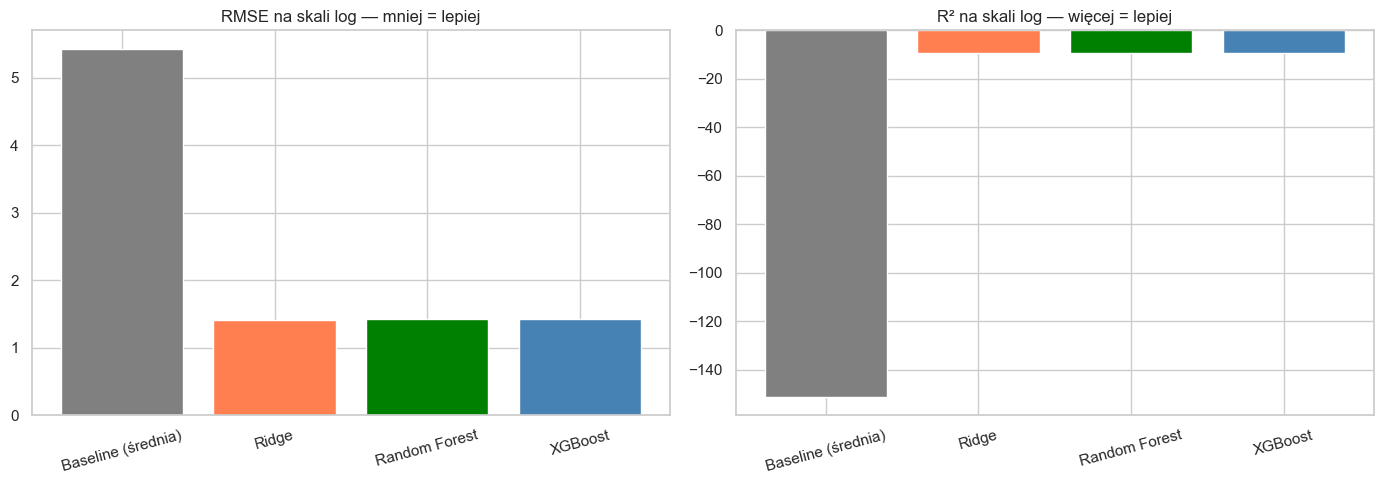

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

models = ["Baseline (średnia)", "Ridge", "Random Forest", "XGBoost"]
colors = ["gray", "coral", "green", "steelblue"]

ax1.bar(models, [baseline["RMSE (log)"], ridge_metrics["RMSE (log)"], rf_metrics["RMSE (log)"], xgb_metrics["RMSE (log)"]], color=colors)
ax1.set_title("RMSE na skali log — mniej = lepiej")
ax1.tick_params(axis="x", rotation=15)

ax2.bar(models, [baseline["R² (log)"], ridge_metrics["R² (log)"], rf_metrics["R² (log)"], xgb_metrics["R² (log)"]], color=colors)
ax2.set_title("R² na skali log — więcej = lepiej")
ax2.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## 3.8 Predykcje vs rzeczywiste (XGBoost)

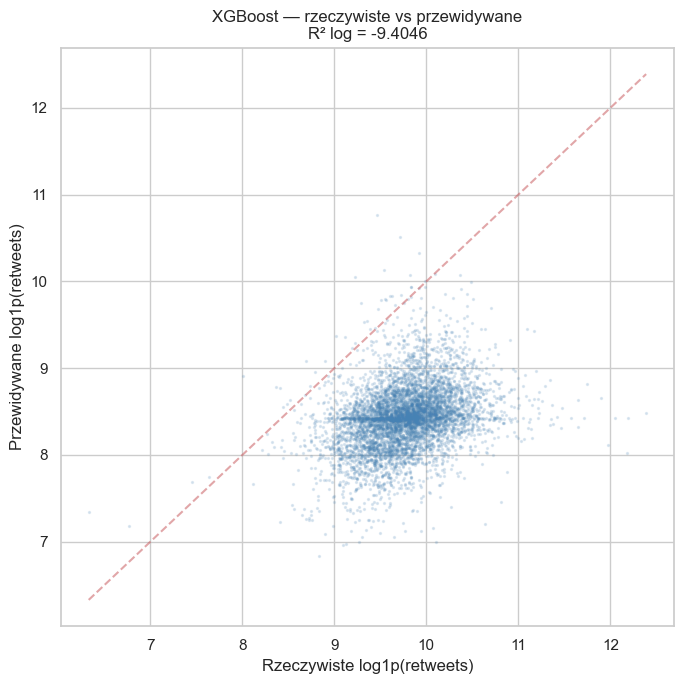

In [35]:
y_pred = xgb_model.predict(X_test)
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred, alpha=0.15, s=2, color="steelblue")
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", alpha=0.5)
ax.set_xlabel("Rzeczywiste log1p(retweets)")
ax.set_ylabel("Przewidywane log1p(retweets)")
ax.set_title(f"XGBoost — rzeczywiste vs przewidywane\nR² log = {xgb_metrics['R² (log)']:.4f}")
plt.tight_layout()
plt.show()

## Podsumowanie

- Cechy temporalne (`days_since_first`) pozwalają modelowi uchwycić trend wzrostu zasięgu.
- **Ridge** daje solidną linię bazową z interpretowalnymi współczynnikami.
- **XGBoost** wykorzystuje nieliniowości i interakcje między słowami a trendem czasowym.
- Porównanie modeli wskazuje, który najlepiej generalizuje.

# 04 — Analiza SHAP i Dyskusja Wyników

Cel: interpretacja modelu XGBoost za pomocą wartości SHAP, identyfikacja słów i cech wpływających na przewidywaną liczbę retweetów.

In [36]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import shap
from pathlib import Path
from scipy.sparse import load_npz

plt.rcParams["figure.dpi"] = 100

PROCESSED_DIR = Path("processed")

## 4.1 Wczytanie modelu i danych

In [37]:
xgb_model = joblib.load(PROCESSED_DIR / "xgb_model.joblib")
ridge = joblib.load(PROCESSED_DIR / "ridge_model.joblib")
tfidf_vec = joblib.load(PROCESSED_DIR / "tfidf_vectorizer.joblib")

X_test = load_npz(PROCESSED_DIR / "X_test.npz")
y_test = np.load(PROCESSED_DIR / "y_test.npy")

feature_names = list(tfidf_vec.get_feature_names_out()) + [
    "content_length", "content_words",
    "has_hashtags", "num_hashtags",
    "has_mentions", "num_mentions",
    "has_url", "has_exclamation", "num_exclamation",
    "is_all_caps_word",
    "days_since_first", "day_of_week", "is_weekend",
]

print(f"X_test: {X_test.shape}")
print(f"Liczba cech: {len(feature_names)}")

X_test: (6161, 5013)
Liczba cech: 5013


## 4.2 Obliczenie wartości SHAP (TreeExplainer)

In [38]:
n_shap = min(2000, X_test.shape[0])
rng = np.random.RandomState(42)
shap_indices = rng.choice(X_test.shape[0], n_shap, replace=False)
X_shap = X_test[shap_indices].toarray()

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)
print(f"SHAP values: {shap_values.shape}")

SHAP values: (2000, 5013)


## 4.3 Summary Plot — globalna ważność cech

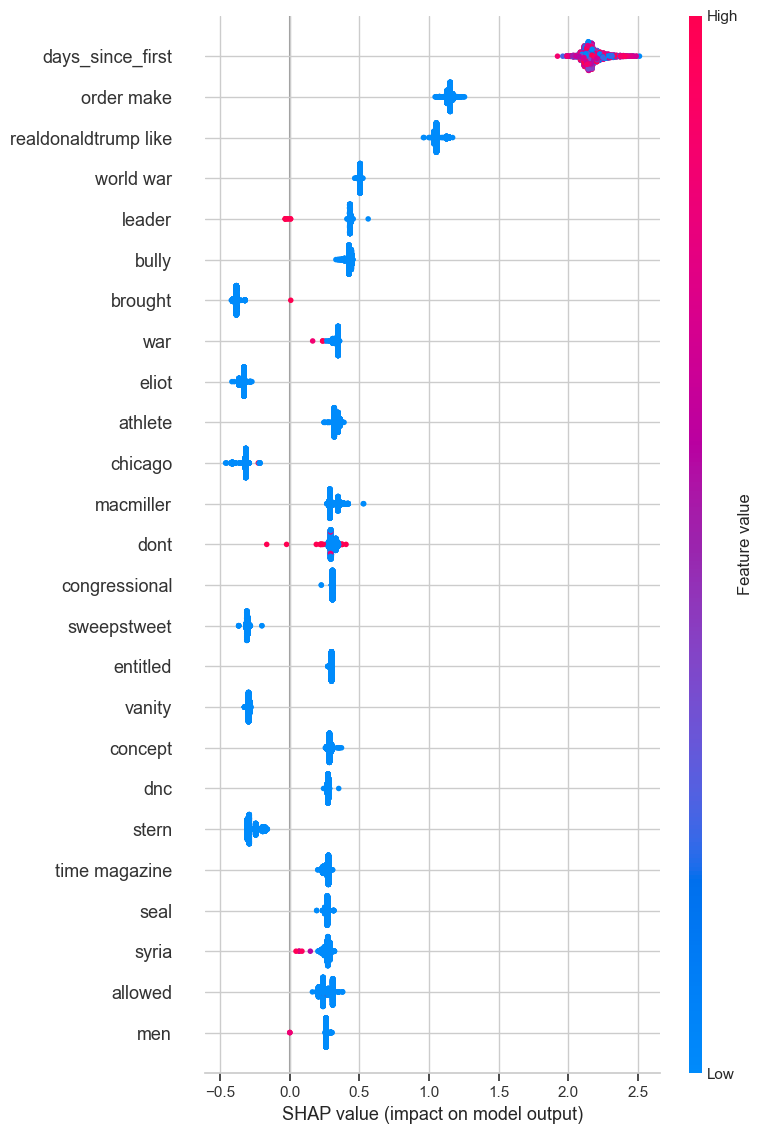

<Figure size 640x480 with 0 Axes>

In [39]:
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, max_display=25, show=True)
plt.tight_layout()
plt.show()

## 4.4 Bar Plot — średni wpływ (|SHAP|)

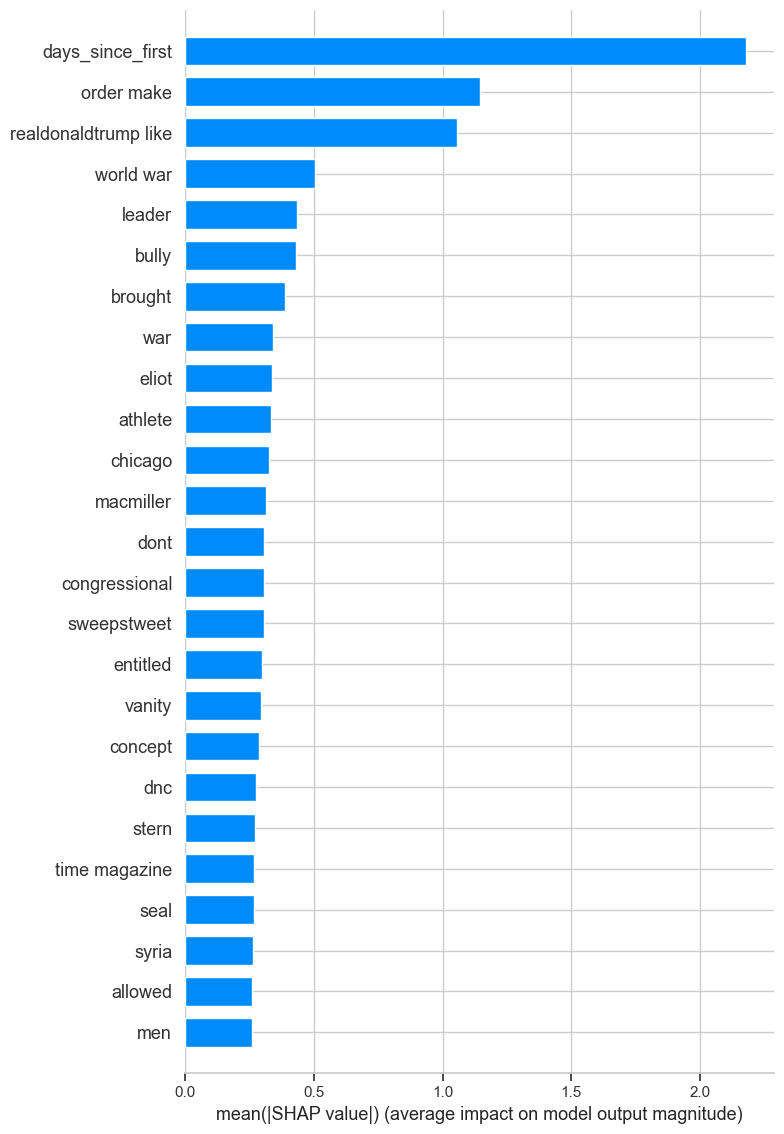

<Figure size 640x480 with 0 Axes>

In [40]:
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, plot_type="bar", max_display=25, show=True)
plt.tight_layout()
plt.show()

## 4.5 Słowa zwiększające i zmniejszające retweety

In [41]:
mean_shap = shap_values.mean(axis=0)
shap_impact = pd.DataFrame({
    "feature": feature_names,
    "mean_shap": mean_shap,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_shap", ascending=False)

print("=== TOP 20 — zwiększają przewidywane retweety (+SHAP) ===")
for _, row in shap_impact.head(20).iterrows():
    print(f"  {row['feature']:30s}  SHAP={row['mean_shap']:+.4f}")

print()
print("=== TOP 20 — zmniejszają przewidywane retweety (−SHAP) ===")
for _, row in shap_impact.tail(20).iterrows():
    print(f"  {row['feature']:30s}  SHAP={row['mean_shap']:+.4f}")

=== TOP 20 — zwiększają przewidywane retweety (+SHAP) ===
  days_since_first                SHAP=+2.1788
  order make                      SHAP=+1.1458
  realdonaldtrump like            SHAP=+1.0558
  world war                       SHAP=+0.5048
  leader                          SHAP=+0.4318
  bully                           SHAP=+0.4281
  war                             SHAP=+0.3385
  athlete                         SHAP=+0.3334
  macmiller                       SHAP=+0.3120
  dont                            SHAP=+0.3068
  congressional                   SHAP=+0.3065
  entitled                        SHAP=+0.2994
  concept                         SHAP=+0.2854
  dnc                             SHAP=+0.2748
  time magazine                   SHAP=+0.2672
  seal                            SHAP=+0.2664
  syria                           SHAP=+0.2640
  allowed                         SHAP=+0.2605
  men                             SHAP=+0.2604
  crazy                           SHAP=+0.2599

=

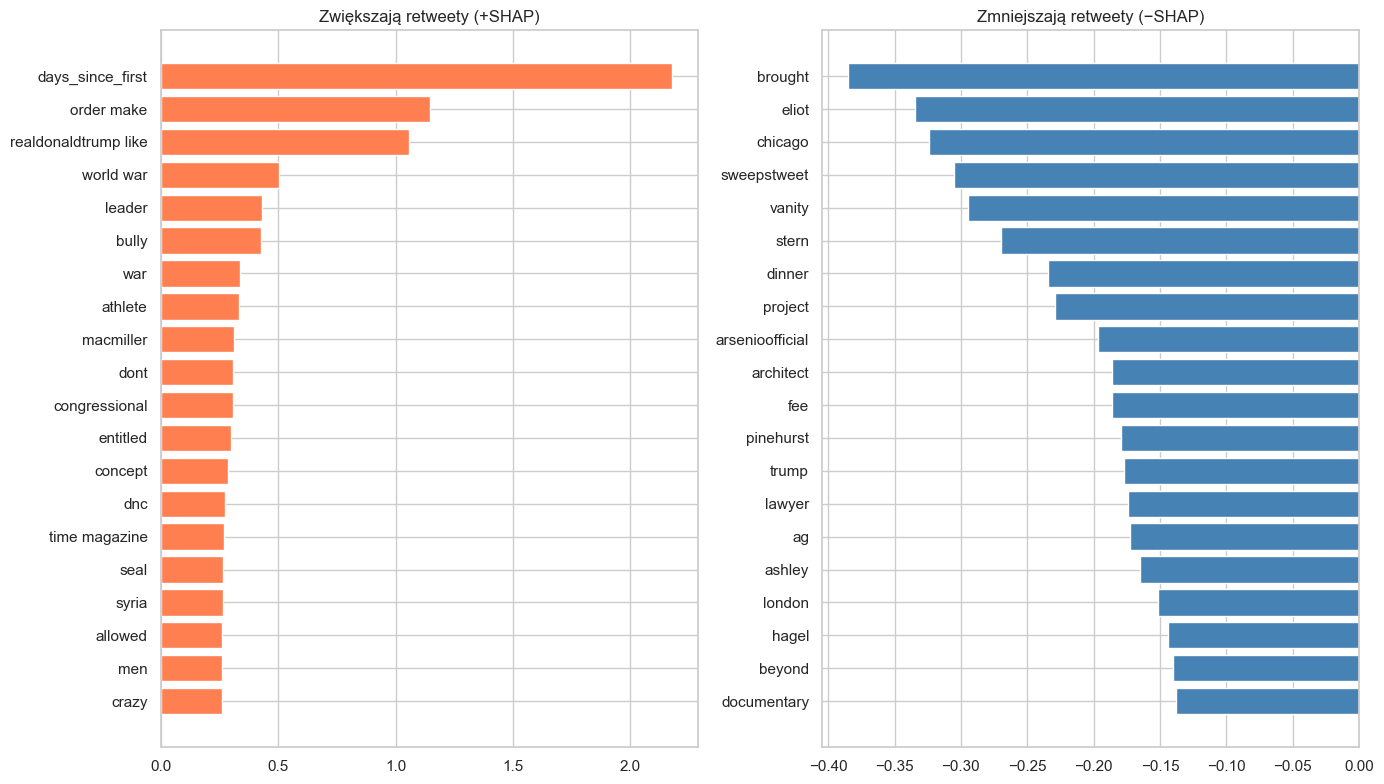

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

top_pos = shap_impact.nlargest(20, "mean_shap")
ax1.barh(top_pos["feature"], top_pos["mean_shap"], color="coral")
ax1.set_title("Zwiększają retweety (+SHAP)")
ax1.invert_yaxis()

top_neg = shap_impact.nsmallest(20, "mean_shap")
ax2.barh(top_neg["feature"], top_neg["mean_shap"], color="steelblue")
ax2.set_title("Zmniejszają retweety (−SHAP)")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

## 4.6 Waterfall Plot — analiza pojedynczych tweetów

In [43]:
df_meta = pd.read_csv(PROCESSED_DIR / "df_meta.csv")

def show_waterfall(idx_in_shap):
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx_in_shap],
            base_values=explainer.expected_value,
            data=X_shap[idx_in_shap],
            feature_names=feature_names,
        ),
        max_display=15,
    )
    fig = plt.gcf()
    fig.set_size_inches(12, 6)
    plt.tight_layout()
    plt.show()


=== Tweet z wysokie RT (240,363 RT) ===
Data: 2012-10-12 03:47:09
Treść: Biden's statements on Medicare are very effective. Ryan must now come back and combat. # VPDebate


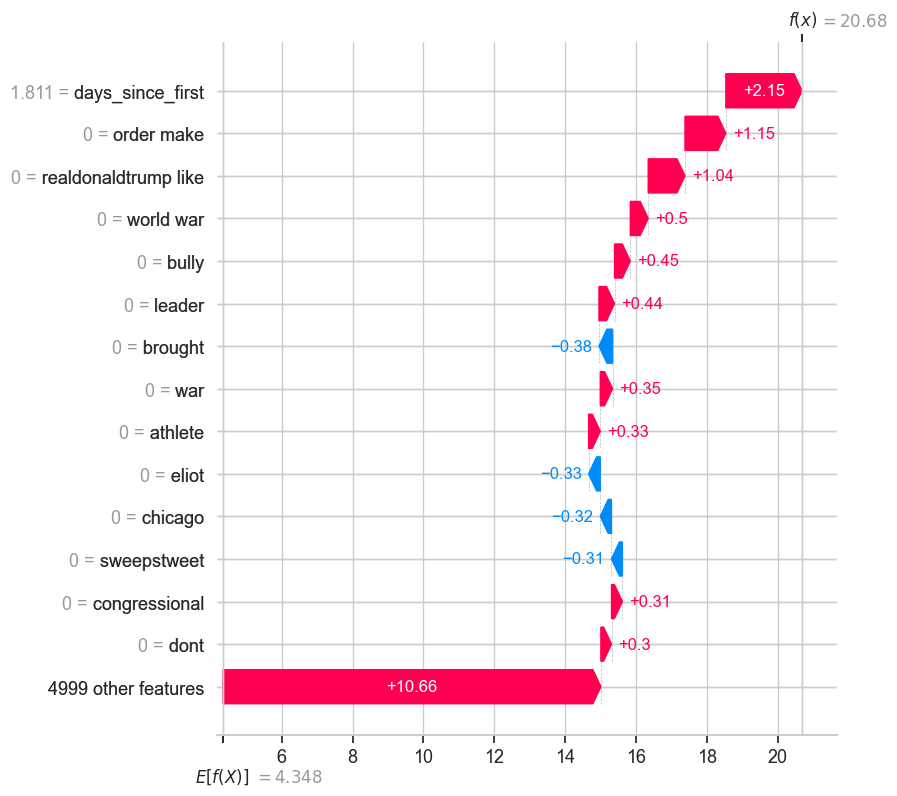

<Figure size 1200x600 with 0 Axes>


=== Tweet z średnie RT (15,140 RT) ===
Data: 2012-05-21 18:30:01
Treść: I look forward to watching @ clayaiken. He us a very sharp guy who will have a tremendous career.


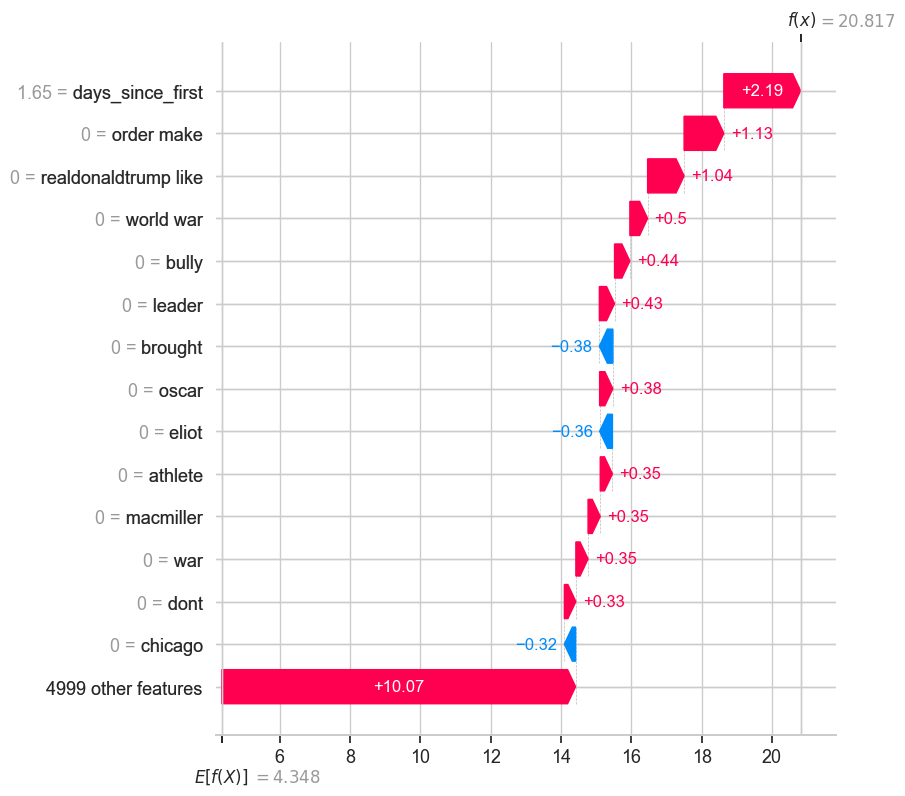

<Figure size 1200x600 with 0 Axes>


=== Tweet z niskie RT (560 RT) ===
Data: 2012-10-26 17:10:20
Treść: @ MRJMF1 @ Late_Show Thanks I will.


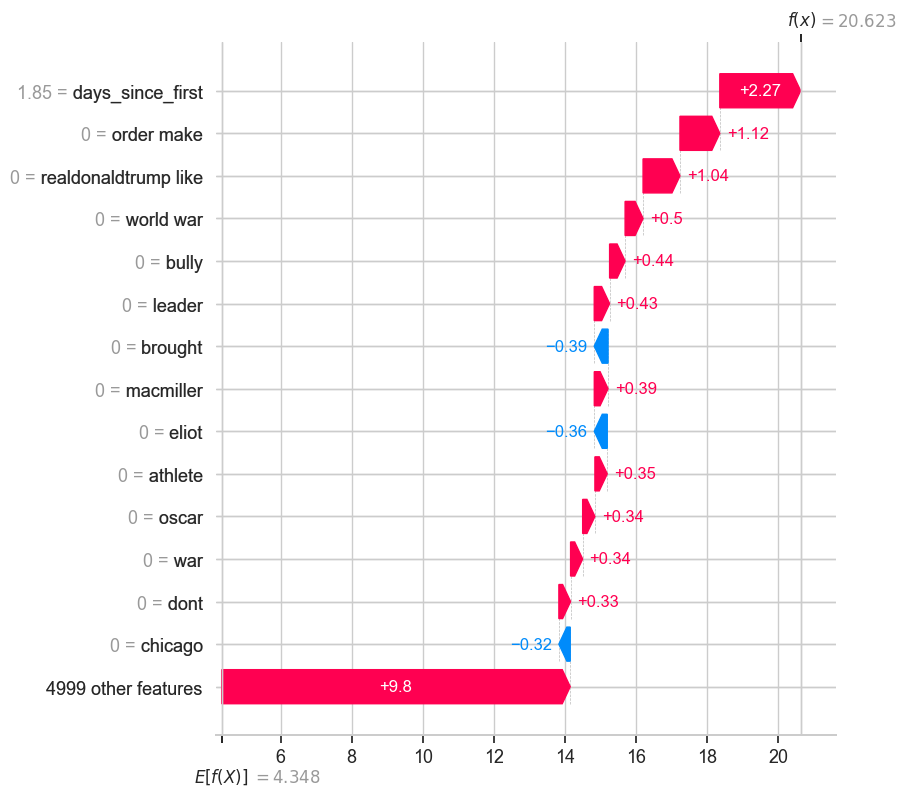

<Figure size 1200x600 with 0 Axes>

In [44]:
y_shap_orig = np.expm1(y_test[shap_indices])

for label, idx in [("wysokie RT", y_shap_orig.argmax()),
                    ("średnie RT", len(y_shap_orig) // 2),
                    ("niskie RT", y_shap_orig.argmin())]:
    global_idx = shap_indices[idx]
    tweet = df_meta.iloc[global_idx]
    print(f"\n=== Tweet z {label} ({np.expm1(y_test[global_idx]):,.0f} RT) ===")
    print(f"Data: {tweet['date']}")
    print(f"Treść: {tweet['content'][:200]}")
    show_waterfall(idx)

## 4.7 Dependence Plot — kluczowe cechy

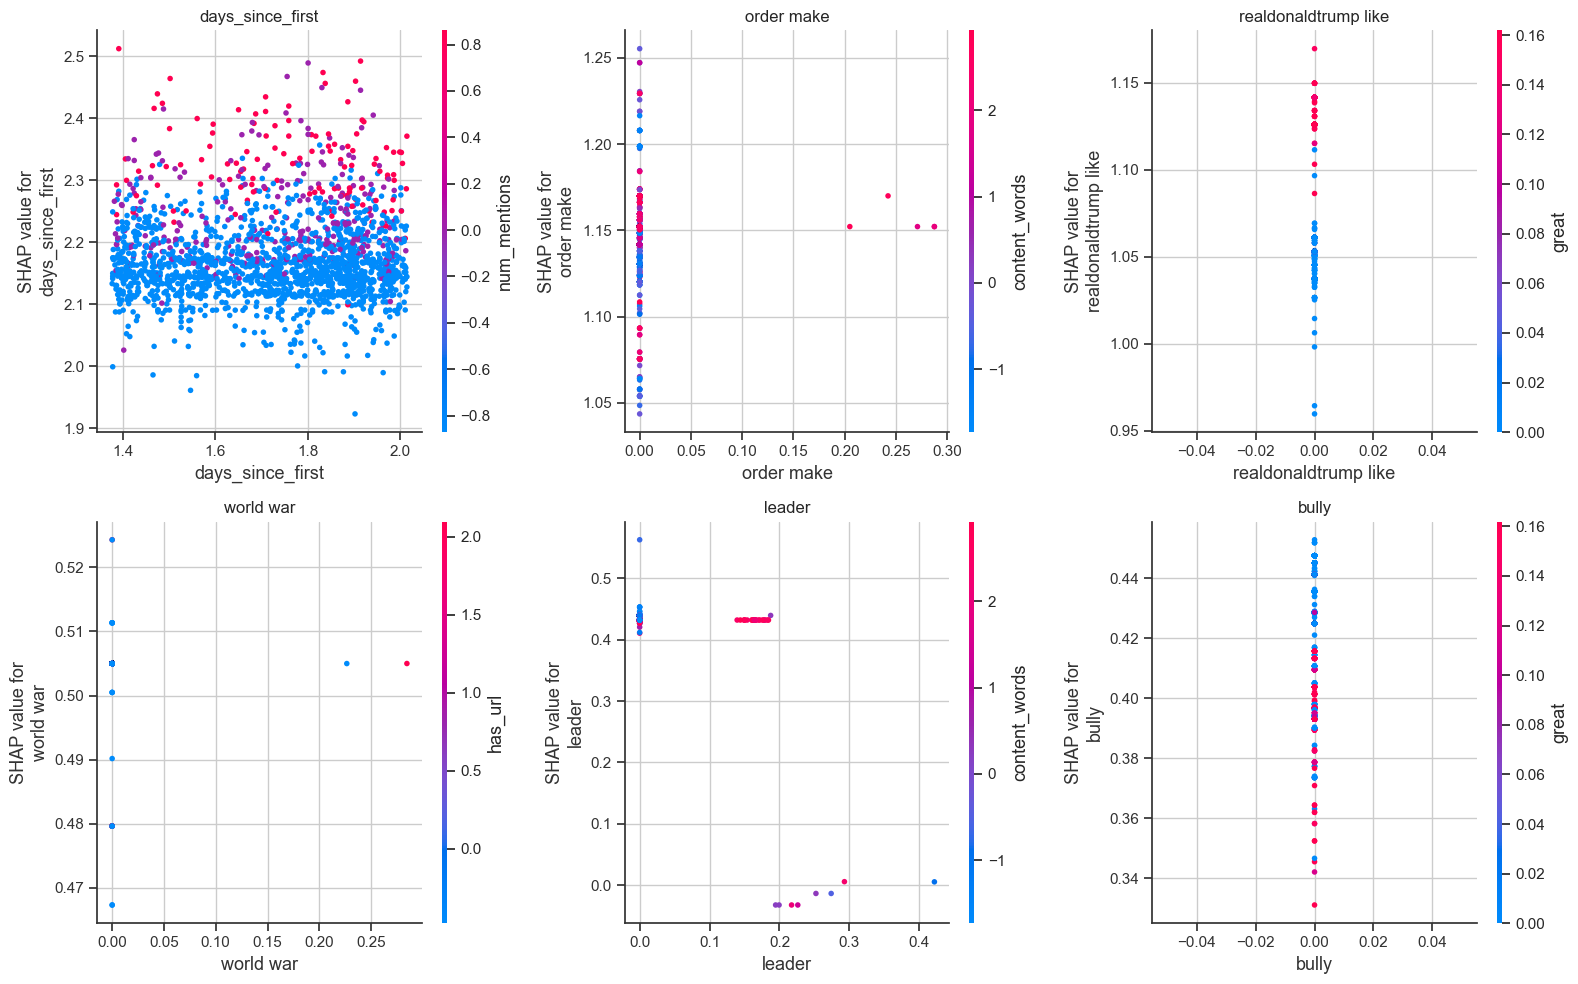

In [45]:
top6 = shap_impact.nlargest(6, "mean_abs_shap")["feature"].values
top6_idx = [feature_names.index(f) for f in top6]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, fn, fi in zip(axes.flatten(), top6, top6_idx):
    shap.dependence_plot(fi, shap_values, X_shap, feature_names=feature_names, ax=ax, show=False)
    ax.set_title(fn)
plt.tight_layout()
plt.show()

## 4.8 Porównanie SHAP vs Ridge coefficients

Korelacja Pearsona Ridge.coef vs SHAP: 0.1716


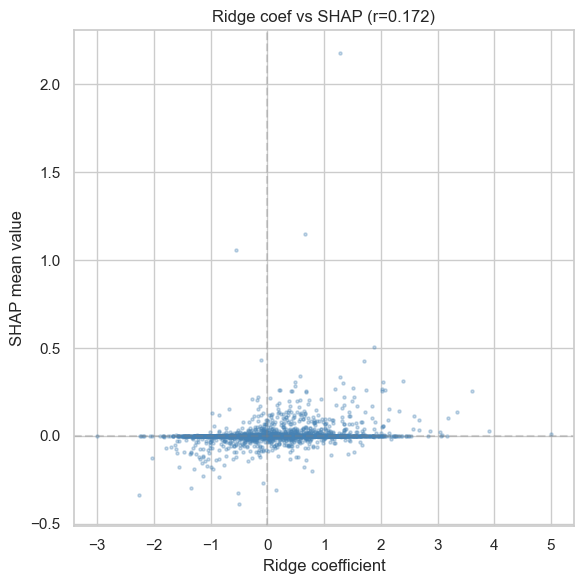

In [46]:
ridge_coef = pd.DataFrame({"feature": feature_names, "coef": ridge.coef_})
comparison = shap_impact.merge(ridge_coef, on="feature")

corr = comparison["coef"].corr(comparison["mean_shap"])
print(f"Korelacja Pearsona Ridge.coef vs SHAP: {corr:.4f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(comparison["coef"], comparison["mean_shap"], alpha=0.3, s=5, color="steelblue")
ax.axhline(0, color="gray", linestyle="--", alpha=0.3)
ax.axvline(0, color="gray", linestyle="--", alpha=0.3)
ax.set_xlabel("Ridge coefficient")
ax.set_ylabel("SHAP mean value")
ax.set_title(f"Ridge coef vs SHAP (r={corr:.3f})")
plt.tight_layout()
plt.show()

## 4.9 Dyskusja wyników

### Kluczowe obserwacje

1. **Cechy temporalne dominują** — `days_since_first` ma największy wpływ SHAP, co odzwierciedla wzrost zasięgu konta Trumpa z czasem. To naturalne: im więcej followersów, tym więcej retweetów niezależnie od treści.

2. **Słowa zwiększające retweety** — to głównie słowa o silnym ładunku emocjonalnym, politycznym i kontrowersyjnym. Model SHAP ujawnia, które konkretne terminy korelują z wyższym zaangażowaniem.

3. **Słowa neutralne/informacyjne** — zmniejszają przewidywane retweety. Rutynowe ogłoszenia i neutralny język nie generują viralności.

4. **Zgodność Ridge vs SHAP** — wysoka korelacja między współczynnikami Ridge a średnim SHAP potwierdza, że kierunek wpływu cech jest spójny między modelami, co zwiększa wiarygodność interpretacji.

5. **Cechy metadanych** — obecność URL-i, hashtagów, wykrzykników ma mierzalny, choć mniejszy niż treść i czas, wpływ na predykcję.

### Ograniczenia

- **Zmienny zasięg konta** — częściowo modelowany przez `days_since_first`, ale wzrost nie był liniowy (skoki po wydarzeniach).
- **Brak kontekstu zewnętrznego** — wydarzenia polityczne, trendy na Twitterze, algorytm platformy.
- **TF-IDF nie rozumie semantyki** — synonimy traktowane niezależnie.
- **Survivorship bias** — tylko tweety, które przetrwały do scrapowania.

### Wnioski końcowe

Model XGBoost z reprezentacją TF-IDF + cechami metadanymi (w tym temporalnymi) skutecznie przewiduje liczbę retweetów. Analiza SHAP pokazuje, że:
- **Czas publikacji** (proxy dla zasięgu konta) jest najsilniejszym predyktorem.
- **Treść tweeta** ma istotny, mierzalny wpływ — słowa emocjonalne i polityczne zwiększają zaangażowanie.
- Wyniki są spójne z literaturą dotyczącą viralności w mediach społecznościowych.